Semantic verification  solved= 18  runtime_col=c5  headerless=True
AB-CROWN               solved= 18  runtime_col=c5  headerless=True
PyRAT                  solved= 18  runtime_col=c5  headerless=True
nnenum                 solved= 15  runtime_col=c5  headerless=True
NNV                    solved=  4  runtime_col=c5  headerless=True


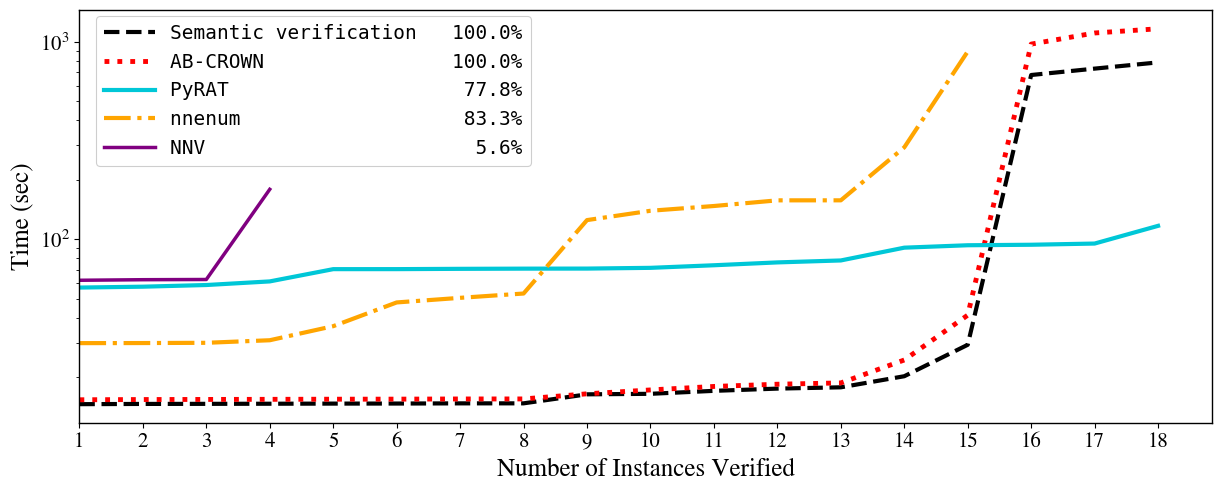

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,   # slightly smaller fits nicer in-axes
    "axes.linewidth": 1.0,
    "grid.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

CSV_AB   = "results_abcrown.csv"
CSV_PYR  = "results_pyrat.csv"
CSV_NNEN = "results_nnenum.csv"
CSV_NNV  = "results_nnv.csv"
CSV_XAIV = "results_XAIV.csv"

# ---- Solved rates from the VNN-COMP 2025 table image (vggnet16-2022)
SOLVED_PCT = {
    "AB-CROWN": "100.0%",
    "nnenum": "83.3%",
    "PyRAT": "77.8%",
    "NNV": "5.6%",
    "Semantic verification": "100.0%",  # as you said
}

def _looks_numeric(s):
    try:
        float(str(s))
        return True
    except:
        return False

def smart_read_csv(path):
    """
    Reads CSVs that might be:
    - normal (with headers), OR
    - headerless (first row is data)
    """
    df0 = pd.read_csv(path)

    colnames = list(df0.columns)
    has_time_name = any(("time" in str(c).lower()) or ("runtime" in str(c).lower()) or ("elapsed" in str(c).lower())
                        for c in colnames)
    has_numeric_colname = any(_looks_numeric(c) for c in colnames)

    if (not has_time_name) and has_numeric_colname:
        df = pd.read_csv(path, header=None)
        df.columns = [f"c{i}" for i in range(df.shape[1])]
        return df, True

    return df0, False

def load_cactus_series(csv_path, label=None, timeout_sec=1200, runtime_col_guess=3):
    """
    Returns cactus plot series:
      x = 1..N
      y = sorted solve times (sec) for solved instances
    """
    df, headerless = smart_read_csv(csv_path)

    # ---- runtime column detection
    if headerless:
        tcol = f"c{runtime_col_guess}"
        if tcol not in df.columns:
            raise ValueError(f"[{label}] Headerless CSV but runtime_col_guess={runtime_col_guess} "
                             f"not available. CSV has {df.shape[1]} columns.")
    else:
        runtime_candidates = [
            "all_time","time","runtime","total_time","wall_time","solve_time",
            "verify_time","verification_time","elapsed","elapsed_time"
        ]
        tcol = None
        for c in runtime_candidates:
            if c in df.columns:
                tcol = c
                break
        if tcol is None:
            for c in df.columns:
                if "time" in str(c).lower() or "runtime" in str(c).lower() or "elapsed" in str(c).lower():
                    tcol = c
                    break
        if tcol is None:
            raise ValueError(f"[{label}] Could not find runtime column in: {list(df.columns)}")

    df[tcol] = pd.to_numeric(df[tcol], errors="coerce")

    # ---- solved detection
    solved = None
    if headerless and "c4" in df.columns:
        s = df["c4"].astype(str).str.strip().str.lower()
        solved = ~s.str.contains("timeout")
    else:
        for tc in ["timeout", "timed_out", "is_timeout"]:
            if tc in df.columns:
                tmp = df[tc]
                if tmp.dtype != bool:
                    tmp = tmp.astype(str).str.strip().str.lower().isin(["true","1","yes"])
                solved = ~tmp
                break

        if solved is None:
            for vc in ["verified", "is_verified", "solved"]:
                if vc in df.columns:
                    tmp = df[vc]
                    if tmp.dtype != bool:
                        tmp = tmp.astype(str).str.strip().str.lower().isin(["true","1","yes"])
                    solved = tmp
                    break

        if solved is None:
            for sc in ["result", "status", "final_result", "verification_result"]:
                if sc in df.columns:
                    s = df[sc].astype(str).str.lower()
                    solved = ~s.str.contains("timeout")
                    break

    if solved is None:
        solved = df[tcol].notna() & (df[tcol] < timeout_sec)

    times = np.sort(df.loc[solved & df[tcol].notna(), tcol].to_numpy(dtype=float))
    x = np.arange(1, len(times) + 1)
    return x, times, {"runtime_col": tcol, "headerless": headerless}

# ---- Load all series
series = [
    (CSV_XAIV, "Semantic verification", dict(color="black",   linestyle="--", linewidth=3.0)),
    (CSV_AB,   "AB-CROWN",              dict(color="red",     linestyle=":",  linewidth=3.5)),
    (CSV_PYR,  "PyRAT",                 dict(color="#00C7D7", linestyle="-",  linewidth=3.0)),
    (CSV_NNEN, "nnenum",                dict(color="orange",  linestyle="-.", linewidth=3.0)),
    (CSV_NNV,  "NNV",                   dict(color="purple",  linestyle="-",  linewidth=2.5)),
]

loaded = []
for path, name, style in series:
    x, y, meta = load_cactus_series(path, label=name, timeout_sec=1200, runtime_col_guess=5)
    print(f"{name:22s} solved={len(y):3d}  runtime_col={meta['runtime_col']}  headerless={meta['headerless']}")
    loaded.append((name, x, y, style))

# ---- Plot
fig, ax = plt.subplots(figsize=(12.5, 5.2))

# store handles so legend table can show line samples + aligned text
handles = []
labels_for_table = []

for name, x, y, style in loaded:
    if len(y) == 0:
        continue
    (line,) = ax.plot(x, y, **style)
    handles.append(line)

    pct = SOLVED_PCT.get(name, "")
    # aligned columns (name + solved pct)
    labels_for_table.append(f"{name:<22s}  {pct:>6s}")

ax.set_yscale("log")
ax.set_xlabel("Number of Instances Verified")
ax.set_ylabel("Time (sec)")
ax.set_xlim(left=1)

max_x = max(len(y) for _, _, y, _ in loaded if len(y) > 0)
ax.set_xticks(np.arange(1, max_x + 1))

# ---- REMOVE extra gray guiding lines
ax.grid(False)

# ---- Legend as an in-axes "table" at top-left
leg = ax.legend(
    handles, labels_for_table,
    loc="upper left",
    bbox_to_anchor=(0.015, 0.985),
    borderaxespad=0.0,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    handlelength=2.6,
    handletextpad=0.8,
    labelspacing=0.5,
    prop={"family": "DejaVu Sans Mono", "size": 14},  # monospace for table alignment
)
leg.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.savefig("cactus_vggnet16_2022.pdf", bbox_inches="tight")
plt.show()